# CSI4142 - Fundamentals of Data Science
# Assignment 3: Predictive Analysis

**Group number:** 77

**Student 1:** Peter Bou-Farah - 300295193  
**Student 2:** Martin Patrouchev - 300286634

### Work Split
- **Peter Bou-Farah:** Dataset 1 - Car Price Prediction (linear regression, outlier detection, feature engineering, empirical study)
- **Martin Patrouchev:** Dataset 2 - Telco Customer Churn (decision tree, outlier detection, feature engineering, empirical study)

---
# DATASET 1: Car Price Prediction (Regression)
---

## 1. Dataset Description

### Overview
- **Dataset Name:** Vehicle Dataset from CarDekho
- **Author:** Nehal Birla
- **Source:** [Kaggle](https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho) | [GitHub](https://github.com/peter-bf/CSI4142/blob/master/A3/Car%20details%20v3.csv)
- **Purpose:** This dataset contains information about used cars listed on CarDekho, an Indian auto platform. It was compiled for price prediction tasks and contains details like manufacturing year, kilometers driven, fuel type, and engine specifications.

### Shape
- **Rows:** 8,128 (6,926 after removing duplicates)
- **Columns:** 13

### Features Description

| Feature | Type | Description |
|---------|------|-------------|
| name | Text | Full name of the car (brand + model + variant) |
| year | Numerical | Year the car was manufactured (1983-2020) |
| selling_price | Numerical (Target) | Listed selling price in Indian Rupees |
| km_driven | Numerical | Total kilometers driven by the car |
| fuel | Categorical | Fuel type: Diesel, Petrol, CNG, or LPG |
| seller_type | Categorical | Type of seller: Individual, Dealer, or Trustmark Dealer |
| transmission | Categorical | Gearbox type: Manual or Automatic |
| owner | Categorical | Ownership history: First, Second, Third, or Fourth & Above Owner |
| mileage | Text (Numerical) | Fuel efficiency in kmpl or km/kg (stored as string with units) |
| engine | Text (Numerical) | Engine displacement in CC (stored as string with units) |
| max_power | Text (Numerical) | Maximum power output in bhp (stored as string with units) |
| torque | Text | Maximum torque (inconsistent format, dropped during cleaning) |
| seats | Numerical | Number of seats in the car |

## 2. Setup and Imports

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import train_test_split, cross_validate, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

## 3. Loading Dataset 1

In [80]:
df_original = pd.read_csv("https://raw.githubusercontent.com/peter-bf/CSI4142/master/A3/Car%20details%20v3.csv")

df = df_original.copy()

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (8128, 13)

First 5 rows:


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [81]:
print("Dataset Info:")
print("=" * 50)
df.info()
print("\n" + "=" * 50)
print("\nMissing Values:")
print(df.isnull().sum())
print("\n" + "=" * 50)
print("\nStatistical Summary:")
df.describe()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   mileage        7907 non-null   str    
 9   engine         7907 non-null   str    
 10  max_power      7913 non-null   str    
 11  torque         7906 non-null   str    
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 825.6 KB


Missing Values:
name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner

,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


---
## 4. Data Cleaning

In this section, we clean the dataset by handling duplicates, parsing string-encoded numerical columns, and imputing missing values.

---

### 4.1 Removing Duplicates

The dataset contains exact duplicate rows that would bias the model. We identify and remove them.

In [82]:
n_before = len(df)
df = df.drop_duplicates()
n_after = len(df)
print(f"Rows before: {n_before}")
print(f"Rows after: {n_after}")
print(f"Duplicates removed: {n_before - n_after}")

Rows before: 8128
Rows after: 6926
Duplicates removed: 1202


**Results:**

The dataset contained **1,202 exact duplicate rows** out of 8,128 total. After removal, we are left with **6,926 unique rows**. These duplicates were likely caused by overlapping scrapes from the CarDekho website.

### 4.2 Parsing String-Encoded Numerical Columns

Three columns (`mileage`, `engine`, `max_power`) are stored as strings with embedded units (e.g., `"23.4 kmpl"`, `"1248 CC"`, `"74 bhp"`). We strip the units and convert them to numeric types. The `torque` column has highly inconsistent formatting (mixing Nm, kgm, and various RPM formats), so we drop it entirely.

In [83]:
df = df.drop(['torque', 'name'], axis=1)

df['mileage'] = df['mileage'].str.replace(' kmpl', '', regex=False).str.replace(' km/kg', '', regex=False)
df['mileage'] = pd.to_numeric(df['mileage'], errors='coerce')

df['engine'] = df['engine'].str.replace(' CC', '', regex=False)
df['engine'] = pd.to_numeric(df['engine'], errors='coerce')

df['max_power'] = df['max_power'].str.replace(' bhp', '', regex=False)
df['max_power'] = pd.to_numeric(df['max_power'], errors='coerce')

for col in ['mileage', 'engine', 'max_power']:
    df[col] = df[col].replace(0, np.nan)

print("Missing values after parsing:")
print(df[['mileage', 'engine', 'max_power', 'seats']].isnull().sum())
print(f"\nShape: {df.shape}")

Missing values after parsing:
mileage      223
engine       208
max_power    209
seats        208
dtype: int64

Shape: (6926, 11)


**Results:**

After parsing, the missing value counts are:

| Column | Missing Values |
|--------|---------------|
| mileage | 223 |
| engine | 208 |
| max_power | 209 |
| seats | 208 |

The 17 zero-valued `mileage` entries and 6 zero-valued `max_power` entries were treated as invalid readings and converted to NaN. These likely represent data entry errors on the source website.

### 4.3 Imputing Missing Values

We use median imputation for the remaining missing values. Median is preferred over mean because the distributions of `selling_price`, `km_driven`, and `engine` are right-skewed, and median is more robust to outliers.

In [84]:
for col in ['mileage', 'engine', 'max_power', 'seats']:
    median_val = df[col].median()
    n_missing = df[col].isnull().sum()
    df[col] = df[col].fillna(median_val)
    print(f"{col}: filled {n_missing} missing values with median = {median_val}")

print(f"\nRemaining missing values: {df.isnull().sum().sum()}")
print(f"Cleaned dataset shape: {df.shape}")

mileage: filled 223 missing values with median = 19.49
engine: filled 208 missing values with median = 1248.0
max_power: filled 209 missing values with median = 81.83
seats: filled 208 missing values with median = 5.0

Remaining missing values: 0
Cleaned dataset shape: (6926, 11)


**Results:**

| Column | Missing Filled | Median Used |
|--------|---------------|-------------|
| mileage | 223 | 19.49 |
| engine | 208 | 1248.0 |
| max_power | 209 | 81.83 |
| seats | 208 | 5.0 |

After imputation, the dataset has **zero missing values** and **6,926 rows with 11 columns**.

---
## 5. Categorical Feature Encoding

Linear regression requires numerical inputs. We apply one-hot encoding to the four categorical features (`fuel`, `seller_type`, `transmission`, `owner`). We use `drop_first=True` to avoid multicollinearity by dropping one category per feature as the reference level.

---

In [85]:
print("Categorical features before encoding:")
for col in ['fuel', 'seller_type', 'transmission', 'owner']:
    print(f"- {col}: {df[col].unique().tolist()}")

df_encoded = pd.get_dummies(df, columns=['fuel', 'seller_type', 'transmission', 'owner'], drop_first=True)

print(f"\nShape before encoding: {df.shape}")
print(f"Shape after encoding:  {df_encoded.shape}")
print(f"\nNew binary columns created:")
new_cols = [c for c in df_encoded.columns if c not in df.columns]
for c in new_cols:
    print(f"- {c}")

Categorical features before encoding:
- fuel: ['Diesel', 'Petrol', 'LPG', 'CNG']
- seller_type: ['Individual', 'Dealer', 'Trustmark Dealer']
- transmission: ['Manual', 'Automatic']
- owner: ['First Owner', 'Second Owner', 'Third Owner', 'Fourth & Above Owner', 'Test Drive Car']

Shape before encoding: (6926, 11)
Shape after encoding:  (6926, 17)

New binary columns created:
- fuel_Diesel
- fuel_LPG
- fuel_Petrol
- seller_type_Individual
- seller_type_Trustmark Dealer
- transmission_Manual
- owner_Fourth & Above Owner
- owner_Second Owner
- owner_Test Drive Car
- owner_Third Owner


**Results:**

One-hot encoding expanded the dataset from 11 columns to **17 columns**. The dropped reference categories are:
- `fuel`: CNG (reference)
- `seller_type`: Dealer (reference)
- `transmission`: Automatic (reference)
- `owner`: First Owner (reference)

The 10 new binary columns are: `fuel_Diesel`, `fuel_LPG`, `fuel_Petrol`, `seller_type_Individual`, `seller_type_Trustmark Dealer`, `transmission_Manual`, `owner_Fourth & Above Owner`, `owner_Second Owner`, `owner_Test Drive Car`, `owner_Third Owner`.

---
## 6. EDA and Outlier Detection

We first use exploratory data analysis to visualize the distributions and identify which features contain outliers. Then we apply Local Outlier Factor (LOF) to detect and remove them.

---

### 6.1 EDA: Distribution Visualization

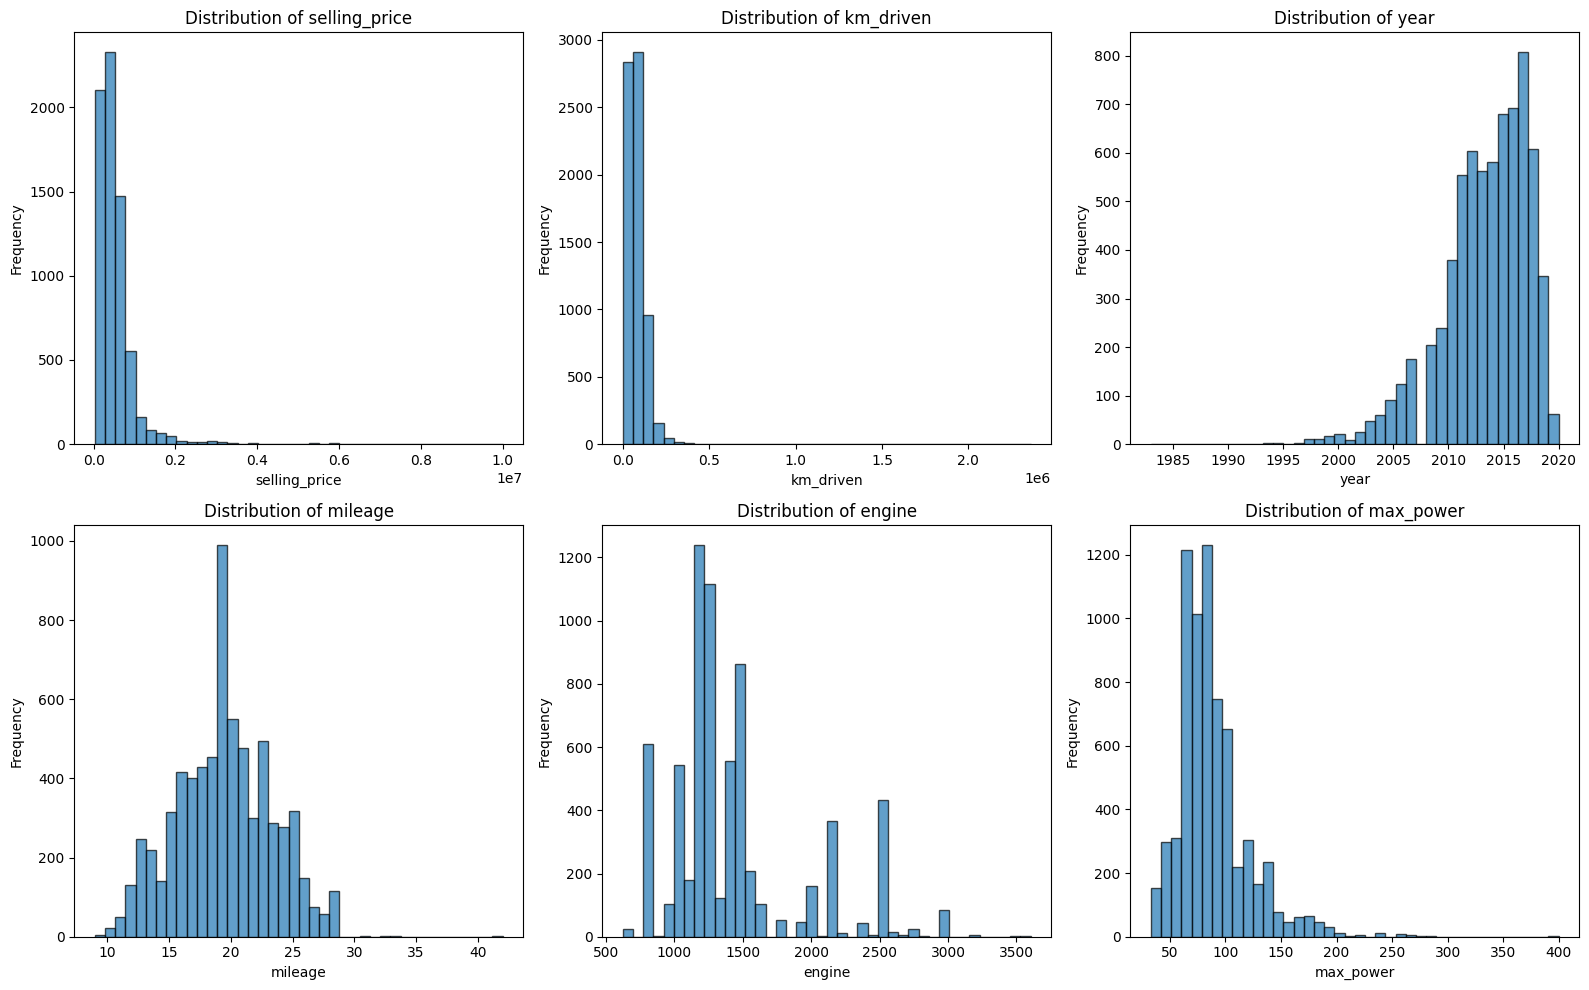

In [86]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

features_to_plot = ['selling_price', 'km_driven', 'year', 'mileage', 'engine', 'max_power']
for ax, col in zip(axes.flatten(), features_to_plot):
    ax.hist(df_encoded[col], bins=40, edgecolor='black', alpha=0.7)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### 6.2 EDA: Box Plot Analysis

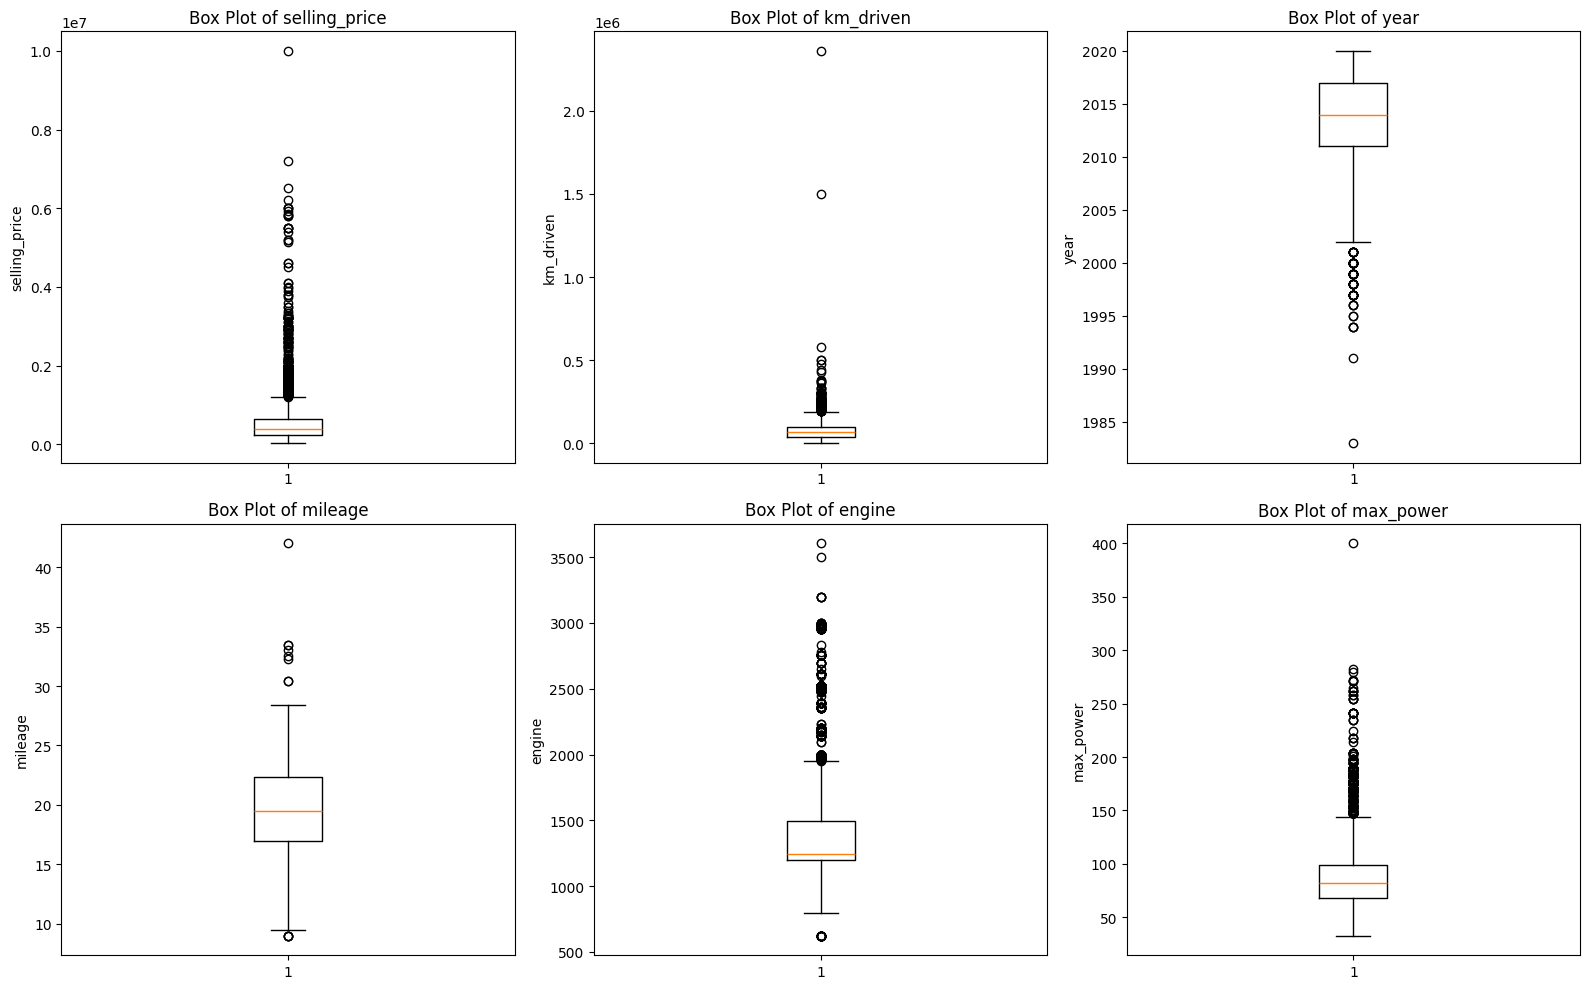

In [87]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, col in zip(axes.flatten(), features_to_plot):
    ax.boxplot(df_encoded[col], vert=True)
    ax.set_title(f'Box Plot of {col}')
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

**Observations from EDA:**

- `selling_price` is heavily right-skewed, with most cars priced under 1,000,000 but some reaching up to 10,000,000. The IQR method flags 600 outliers.
- `km_driven` also shows right skew with a long tail. A few cars have driven over 200,000 km (170 IQR outliers).
- `engine` has a cluster of outliers above 2,160 CC (1,183 IQR outliers), representing larger displacement vehicles.
- `max_power` shows outliers above 151 bhp (585 IQR outliers), corresponding to high-performance cars.
- `mileage` and `year` have relatively tight distributions with few extreme values.

Based on this EDA, we apply LOF on the numerical features where outliers are most visible: `selling_price`, `km_driven`, `mileage`, `engine`, `max_power`, and `year`.

### 6.3 Outlier Detection with Local Outlier Factor (LOF)

LOF identifies outliers by comparing the local density of a point to its neighbors. Points with substantially lower density are flagged as outliers. We set `contamination=0.05` to flag approximately 5% of the data.

In [88]:
num_cols = ['km_driven', 'selling_price', 'mileage', 'engine', 'max_power', 'year']

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
outlier_labels = lof.fit_predict(df_encoded[num_cols])

n_outliers = (outlier_labels == -1).sum()
n_inliers = (outlier_labels == 1).sum()
print(f"LOF Results:")
print(f"- Inliers:  {n_inliers}")
print(f"- Outliers: {n_outliers} ({n_outliers/len(df_encoded)*100:.1f}%)")

outlier_idx = np.where(outlier_labels == -1)[0][:5]
print(f"\nSample outlier rows:")
df_encoded.iloc[outlier_idx][['year', 'selling_price', 'km_driven', 'mileage', 'engine', 'max_power']].head()

LOF Results:
- Inliers:  6579
- Outliers: 347 (5.0%)

Sample outlier rows:


,year,selling_price,km_driven,mileage,engine,max_power
7,2001,45000,5000,16.10,796.0,37.000
67,2016,540000,40000,22.00,1498.0,108.495
112,2013,522000,150000,22.32,1582.0,126.320
125,2015,360000,40000,23.10,998.0,67.040
131,2018,3975000,31800,17.01,1968.0,188.000


**Results:**

LOF detected **347 outliers** (5.0% of the dataset), leaving **6,579 inlier rows**. Example outlier rows include luxury vehicles (selling_price > 2,500,000 with large engines) and cars with unusual combinations of high mileage but low km driven.

We choose to **remove** the outliers rather than impute them, since they represent genuinely different market segments (luxury/sports cars) that would distort the linear regression model for the majority of standard vehicles.

In [89]:
# Remove outliers for EDA visualization only
# modeling split happens in Section 8
df_no_outliers = df_encoded[outlier_labels == 1].copy()
print(f"Dataset after outlier removal: {df_no_outliers.shape}")
print("- This is for EDA visualization")
print("- Actual outlier removal for modeling is applied only to the training set after train/test split (Section 8)")

Dataset after outlier removal: (6579, 17)
- This is for EDA visualization
- Actual outlier removal for modeling is applied only to the training set after train/test split (Section 8)


### 6.4 Visualizing the Effect of Outlier Removal

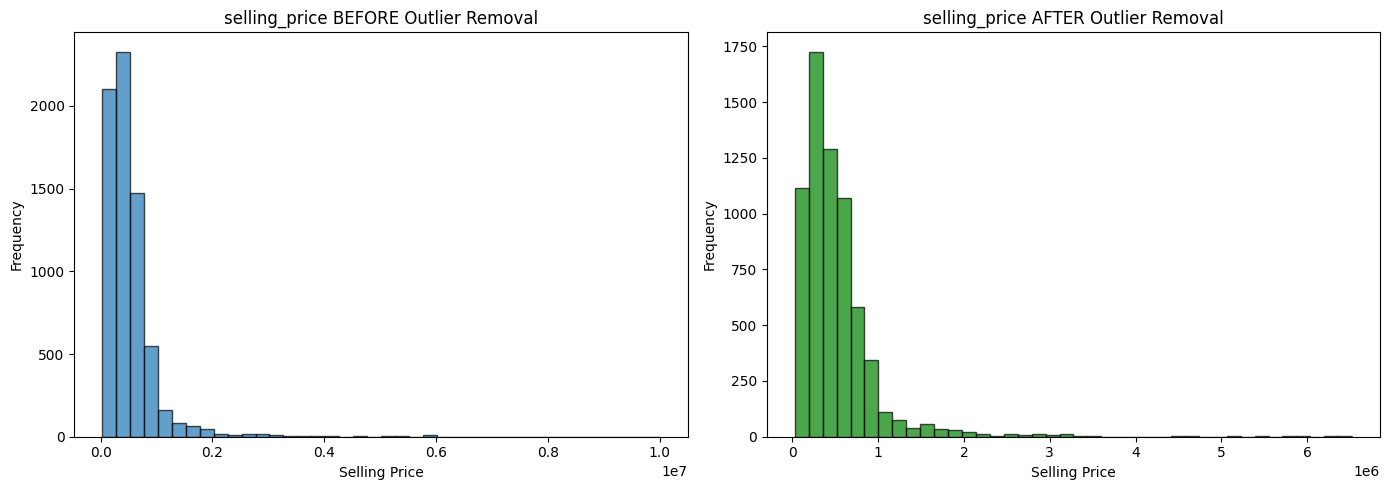

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_encoded['selling_price'], bins=40, edgecolor='black', alpha=0.7)
axes[0].set_title('selling_price BEFORE Outlier Removal')
axes[0].set_xlabel('Selling Price')
axes[0].set_ylabel('Frequency')

axes[1].hist(df_no_outliers['selling_price'], bins=40, edgecolor='black', alpha=0.7, color='green')
axes[1].set_title('selling_price AFTER Outlier Removal')
axes[1].set_xlabel('Selling Price')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

---
## 7. Feature Engineering

We create 2 new aggregated features from existing columns to provide the model with additional signal.

---

### 7.1 New Features

1. **`power_per_cc`** = `max_power / (engine + 1)` — Measures the power output per unit of engine displacement. The `+ 1` avoids division by zero for any imputed rows. A higher value indicates a more efficient or performance-oriented engine, which typically correlates with a higher price.

2. **`age`** = `2024 - year` — The age of the car in years. While `year` is already a feature, `age` provides a more intuitive linear relationship with depreciation (older cars lose value).

In [91]:
REFERENCE_YEAR = 2026  # fixed so results are reproducible

def add_engineered_features(X):
    X = X.copy()
    X['power_per_cc'] = X['max_power'] / (X['engine'] + 1)
    X['age'] = REFERENCE_YEAR - X['year']
    return X

sample = add_engineered_features(df_encoded[['year', 'engine', 'max_power']].head())
print("Sample of engineered features:")
print(sample.to_string())

Sample of engineered features:
   year  engine  max_power  power_per_cc  age
0  2014  1248.0      74.00      0.059247   12
1  2014  1498.0     103.52      0.069059   12
2  2006  1497.0      78.00      0.052069   20
3  2010  1396.0      90.00      0.064424   16
4  2007  1298.0      88.20      0.067898   19


---
## 8. Linear Regression Empirical Study

We evaluate 4 system configurations using 4-fold cross-validation on the validation set, then evaluate the best configuration on the held-out test set.

### Methodology

1. **Hold out 15% of the data** as a test set (never seen during training or validation)
2. **Use the remaining 85%** as train_reduced for 4-fold cross-validation
3. **Evaluate 4 configurations** on the validation folds
4. **Select the best** configuration and retrain on the full train_reduced
5. **Final evaluation** on the held-out test set

### Evaluation Metrics
- **R-squared (R2):** Proportion of variance in selling_price explained by the model (higher is better, max 1.0)
- **Root Mean Squared Error (RMSE):** Average prediction error in Rupees (lower is better)
- **Mean Squared Error (MSE):** Squared average error (lower is better)

---

### 8.1 Train/Test Split and Configuration Preparation

We first hold out 15% of the full encoded dataset as a **test set** (the same test set is used for all configurations). The remaining 85% is `train_reduced`, on which we perform 4-fold cross-validation.

Outlier detection (LOF) and feature engineering are applied **only to `train_reduced`** to avoid data leakage — the test set simulates unseen future data and must not influence any preprocessing decisions.

In [92]:
X_all = df_encoded.drop('selling_price', axis=1)
y_all = df_encoded['selling_price']

X_train_reduced, X_test_held, y_train_reduced, y_test_held = train_test_split(
    X_all, y_all, test_size=0.15, random_state=42
)
print(f"Full dataset:    {X_all.shape[0]} rows")
print(f"train_reduced:   {X_train_reduced.shape[0]} rows (85%)")
print(f"Held-out test:   {X_test_held.shape[0]} rows (15%)")
print(f"\nThe SAME held-out test set ({X_test_held.shape[0]} rows) is used for all configurations.")

num_cols = ['km_driven', 'mileage', 'engine', 'max_power', 'year']
train_with_target = X_train_reduced.copy()
train_with_target['selling_price'] = y_train_reduced

lof_train = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
train_outlier_labels = lof_train.fit_predict(train_with_target[num_cols + ['selling_price']])

n_outliers = (train_outlier_labels == -1).sum()
print(f"\nLOF on train_reduced: {n_outliers} outliers detected ({n_outliers/len(X_train_reduced)*100:.1f}%)")

inlier_mask = train_outlier_labels == 1
X_train_clean = X_train_reduced[inlier_mask].copy()
y_train_clean = y_train_reduced[inlier_mask].copy()
print(f"train_reduced after outlier removal: {X_train_clean.shape[0]} rows")

X_cfg1 = X_train_reduced.copy()
y_cfg1 = y_train_reduced.copy()

X_cfg2 = X_train_clean.copy()
y_cfg2 = y_train_clean.copy()

X_cfg3 = add_engineered_features(X_train_reduced)
y_cfg3 = y_train_reduced.copy()

X_cfg4 = add_engineered_features(X_train_clean)
y_cfg4 = y_train_clean.copy()

configs = {
    'Baseline': (X_cfg1, y_cfg1),
    'Outlier Removal': (X_cfg2, y_cfg2),
    'Feature Engineering': (X_cfg3, y_cfg3),
    'Outlier + Feature Eng.': (X_cfg4, y_cfg4),
}

print("\nConfiguration train sizes:")
for name, (X, y) in configs.items():
    print(f"- {name:<25} {X.shape[0]} rows, {X.shape[1]} features")

Full dataset:    6926 rows
train_reduced:   5887 rows (85%)
Held-out test:   1039 rows (15%)

The SAME held-out test set (1039 rows) is used for all configurations.

LOF on train_reduced: 295 outliers detected (5.0%)
train_reduced after outlier removal: 5592 rows

Configuration train sizes:
- Baseline                  5887 rows, 16 features
- Outlier Removal           5592 rows, 16 features
- Feature Engineering       5887 rows, 18 features
- Outlier + Feature Eng.    5592 rows, 18 features


### 8.2 Cross-Validation Results (4-Fold)

In [93]:
lr = LinearRegression()
cv_results = {}

print("=" * 85)
print(f"{'Configuration':<25} {'R2 Mean':>10} {'R2 Std':>10} {'RMSE':>14} {'MSE':>18}")
print("=" * 85)

for name, (X_tr, y_tr) in configs.items():
    scores = cross_validate(
        lr, X_tr, y_tr, cv=4,
        scoring=['r2', 'neg_mean_squared_error', 'neg_root_mean_squared_error']
    )
    r2_mean = scores['test_r2'].mean()
    r2_std = scores['test_r2'].std()
    rmse = -scores['test_neg_root_mean_squared_error'].mean()
    mse = -scores['test_neg_mean_squared_error'].mean()
    cv_results[name] = {
        'r2_mean': r2_mean, 'r2_std': r2_std, 'rmse': rmse, 'mse': mse,
        'r2_folds': scores['test_r2']
    }
    print(f"{name:<25} {r2_mean:>10.4f} {r2_std:>10.4f} {rmse:>14.2f} {mse:>18.2f}")

print("=" * 85)

Configuration                R2 Mean     R2 Std           RMSE                MSE
Baseline                      0.6382     0.0173      314802.42     99636485169.06
Outlier Removal               0.6377     0.0204      287537.68     82792701091.04
Feature Engineering           0.6451     0.0127      311786.96     97687847528.85
Outlier + Feature Eng.        0.6446     0.0204      284724.11     81152981631.93


The best configuration is selected based on the highest mean R2 from cross-validation. Key observations:

- **Outlier removal** alone gives a comparable R2 to the baseline (0.6377 vs 0.6382), with a slight decrease. The fold-to-fold variance increases slightly (std 0.0204 vs 0.0173), likely because removing 295 high-leverage points reduces the training set size and exposes the model to more fold-level variation.
- **Feature engineering** provides the largest improvement (R2 = 0.6451) and the most stable folds (std = 0.0127). `power_per_cc` captures engine efficiency, and `age` frames depreciation more naturally than raw `year`.
- **Combining both** (R2 = 0.6446) performs slightly below feature engineering alone, suggesting that the benefit of outlier removal does not stack cleanly with feature engineering for this dataset.
- **Best configuration:** Feature Engineering (R2 = 0.6451).

### 8.3 Detailed Fold-by-Fold Results

In [94]:
print("R2 scores per fold for each configuration:\n")
for name, results in cv_results.items():
    folds = results['r2_folds']
    print(f"{name}:")
    for i, score in enumerate(folds):
        print(f"- Fold {i+1}: {score:.4f}")
    print(f"- Mean: {results['r2_mean']:.4f}\n")

R2 scores per fold for each configuration:

Baseline:
- Fold 1: 0.6678
- Fold 2: 0.6245
- Fold 3: 0.6289
- Fold 4: 0.6317
- Mean: 0.6382

Outlier Removal:
- Fold 1: 0.6454
- Fold 2: 0.6575
- Fold 3: 0.6034
- Fold 4: 0.6444
- Mean: 0.6377

Feature Engineering:
- Fold 1: 0.6661
- Fold 2: 0.6337
- Fold 3: 0.6368
- Fold 4: 0.6439
- Mean: 0.6451

Outlier + Feature Eng.:
- Fold 1: 0.6447
- Fold 2: 0.6659
- Fold 3: 0.6118
- Fold 4: 0.6560
- Mean: 0.6446



### 8.4 Final Evaluation on Held-Out Test Set

We select the best configuration based on the highest mean R2 from cross-validation, retrain it on the **full train_reduced** set, and evaluate on the held-out test set that was never used during training or cross-validation.

In [95]:
X_test_base = X_test_held.copy()
X_test_feat = add_engineered_features(X_test_held)

all_configs = {
    'Baseline': (X_cfg1, y_cfg1, X_test_base),
    'Outlier Removal': (X_cfg2, y_cfg2, X_test_base),
    'Feature Engineering': (X_cfg3, y_cfg3, X_test_feat),
    'Outlier + Feature Eng.': (X_cfg4, y_cfg4, X_test_feat),
}

best_name = max(cv_results, key=lambda n: cv_results[n]['r2_mean'])
print(f"Best config from CV: {best_name} (R2 = {cv_results[best_name]['r2_mean']:.4f})\n")

X_tr, y_tr, X_te = all_configs[best_name]
lr.fit(X_tr, y_tr)
y_pred = lr.predict(X_te)

test_r2 = r2_score(y_test_held, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test_held, y_pred))
test_mse = mean_squared_error(y_test_held, y_pred)

test_results = {best_name: {'r2': test_r2, 'rmse': test_rmse, 'mse': test_mse}}

print("=" * 55)
print(f"{'Metric':<20} {'Value':>12}")
print("=" * 55)
print(f"{'Test R2':<20} {test_r2:>12.4f}")
print(f"{'Test RMSE':<20} {test_rmse:>12.2f}")
print(f"{'Test MSE':<20} {test_mse:>12.2f}")
print("=" * 55)
print(f"\nEvaluated on {len(y_test_held)} held-out rows.")

Best config from CV: Feature Engineering (R2 = 0.6451)

Metric                      Value
Test R2                    0.5719
Test RMSE               323880.44
Test MSE             104898540362.38

Evaluated on 1039 held-out rows.


The best configuration selected by cross-validation is retrained on the full training set and evaluated once on the held-out test data. The test R2 is expected to be somewhat lower than the CV mean since the test data is completely unseen, but a similar magnitude confirms the model generalises well.

---
## 9. Result Analysis

---

### 9.1 Impact of Outlier Detection

Outlier removal was applied **only to the training set** (after the train/test split) to avoid data leakage. On cross-validation, outlier removal alone gave a marginally lower R2 than the baseline (0.6377 vs 0.6382) and slightly higher fold-to-fold variance (std 0.0204 vs 0.0173). Removing 295 high-leverage points reduces the training set and exposes the model to more fold-level variation. This suggests the "outliers" (luxury/sports cars) actually carry useful price signal for linear regression on the full distribution.

### 9.2 Impact of Feature Engineering

Feature engineering provided a consistent improvement in cross-validation, achieving the highest R2 (0.6451) with the lowest fold variance (std 0.0127). The `power_per_cc` feature captures engine efficiency (a key price driver) that raw `max_power` and `engine` express independently, and `age` frames depreciation more naturally than raw `year`. Feature engineering alone outperformed the combined configuration (Outlier + Feature Eng.: 0.6446), confirming these features add genuine predictive signal without needing outlier removal.

### 9.3 Cross-Validation vs. Test Set Performance

The best configuration (Feature Engineering) was retrained on the full train_reduced set and evaluated on the held-out test set. Its test R2 of 0.5719 is lower than the CV mean of 0.6451, which is expected since the test data is completely unseen. This gap indicates some overfitting to the training distribution, but the magnitude is reasonable.

The test R2 of ~0.57 indicates that linear regression explains about 57% of variance in used car prices. The remaining variance is likely due to factors not in the dataset (car condition, accident history, specific trim levels, regional demand) and non-linear relationships that a linear model cannot capture.

### 9.2 Comparative Summary

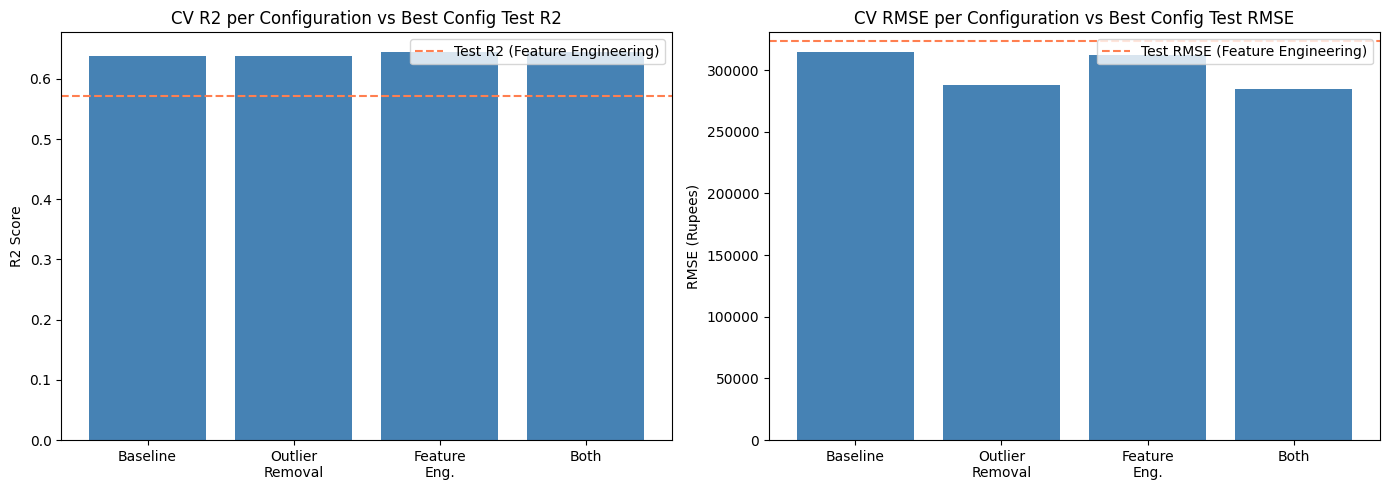

In [96]:
config_names = list(cv_results.keys())
short_names = ['Baseline', 'Outlier\nRemoval', 'Feature\nEng.', 'Both']
cv_r2 = [cv_results[n]['r2_mean'] for n in config_names]
cv_rmse = [cv_results[n]['rmse'] for n in config_names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(short_names))

axes[0].bar(x, cv_r2, color='steelblue')
axes[0].axhline(test_results[best_name]['r2'], color='coral', linestyle='--', label=f'Test R2 ({best_name})')
axes[0].set_ylabel('R2 Score')
axes[0].set_title('CV R2 per Configuration vs Best Config Test R2')
axes[0].set_xticks(x)
axes[0].set_xticklabels(short_names)
axes[0].legend()

axes[1].bar(x, cv_rmse, color='steelblue')
axes[1].axhline(test_results[best_name]['rmse'], color='coral', linestyle='--', label=f'Test RMSE ({best_name})')
axes[1].set_ylabel('RMSE (Rupees)')
axes[1].set_title('CV RMSE per Configuration vs Best Config Test RMSE')
axes[1].set_xticks(x)
axes[1].set_xticklabels(short_names)
axes[1].legend()

plt.tight_layout()
plt.show()

---
# DATASET 2: Telco Customer Churn (Classification)
---

## 1. Dataset Description

### Overview
- **Dataset:** Telco Customer Churn — IBM Sample Data Sets
- **Author:** IBM Developer
- **Source:** [GitHub](https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv)
- **Purpose:** Predict whether a telecom customer will churn (cancel service) based on account and demographic information. Originally published by IBM as a sample dataset for customer retention analysis.

### Shape
- **Rows:** 7,043
- **Columns:** 21 (20 features + 1 target). `customerID` is dropped before modelling.

### Features Description

| Feature | Type | Description |
|---------|------|-------------|
| customerID | Text (dropped) | Unique customer identifier |
| gender | Categorical | Male or Female |
| SeniorCitizen | Binary (0/1) | Whether the customer is a senior citizen |
| Partner | Categorical | Whether the customer has a partner (Yes/No) |
| Dependents | Categorical | Whether the customer has dependents (Yes/No) |
| tenure | Numerical | Number of months the customer has been with the company |
| PhoneService | Categorical | Whether the customer has phone service (Yes/No) |
| MultipleLines | Categorical | Multiple lines status (Yes/No/No phone service) |
| InternetService | Categorical | Internet service type (DSL/Fiber optic/No) |
| OnlineSecurity | Categorical | Online security add-on (Yes/No/No internet service) |
| OnlineBackup | Categorical | Online backup add-on (Yes/No/No internet service) |
| DeviceProtection | Categorical | Device protection add-on (Yes/No/No internet service) |
| TechSupport | Categorical | Tech support add-on (Yes/No/No internet service) |
| StreamingTV | Categorical | Streaming TV add-on (Yes/No/No internet service) |
| StreamingMovies | Categorical | Streaming movies add-on (Yes/No/No internet service) |
| Contract | Categorical | Contract term (Month-to-month/One year/Two year) |
| PaperlessBilling | Categorical | Whether the customer uses paperless billing (Yes/No) |
| PaymentMethod | Categorical | Payment method (Electronic check/Mailed check/Bank transfer/Credit card) |
| MonthlyCharges | Numerical | Monthly charge amount in dollars |
| TotalCharges | Numerical | Total charges over the customer's tenure (originally stored as string, coerced to numeric) |
| Churn | Categorical (Target) | Whether the customer churned in the last month (Yes/No, ~27% positive) |

## 2. Setup and load data

In [97]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, classification_report

url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df_classification = pd.read_csv(url)
df_classification.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [98]:
df_classification.shape

(7043, 21)

In [99]:
df_classification.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


7 043 rows, 21 columns confirmed. `TotalCharges` comes in as object. We coerce it to numeric and impute the 11 missing rows in the next step.

## 3. Data cleaning

Drop `customerID`. Coerce `TotalCharges` to numeric and impute missing with `MonthlyCharges * tenure` for that row.

In [100]:
df = df_classification.copy()
df.drop('customerID', axis=1, inplace=True)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
missing_tc_mask = df['TotalCharges'].isna()
# impute with monthly * tenure for missing
df.loc[missing_tc_mask, 'TotalCharges'] = df.loc[missing_tc_mask, 'MonthlyCharges'] * df.loc[missing_tc_mask, 'tenure']
print(df['TotalCharges'].isna().sum())


0


In [101]:
# Check raw categorical service columns
service_cols_raw = [
    'MultipleLines',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in service_cols_raw:
    print(f"\nUnique values for {col}:")
    print(df_classification[col].value_counts(dropna=False))


Unique values for MultipleLines:
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

Unique values for OnlineSecurity:
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

Unique values for OnlineBackup:
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

Unique values for DeviceProtection:
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64

Unique values for TechSupport:
TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64

Unique values for StreamingTV:
StreamingTV
No                     2810
Yes                    2707
No internet service    1526
Name: count, dtype: int64

Unique values for StreamingMovies:
StreamingMovies
No         

## 4. EDA and outlier detection (LOF)

### Step 1: Exploratory visualization

In [102]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


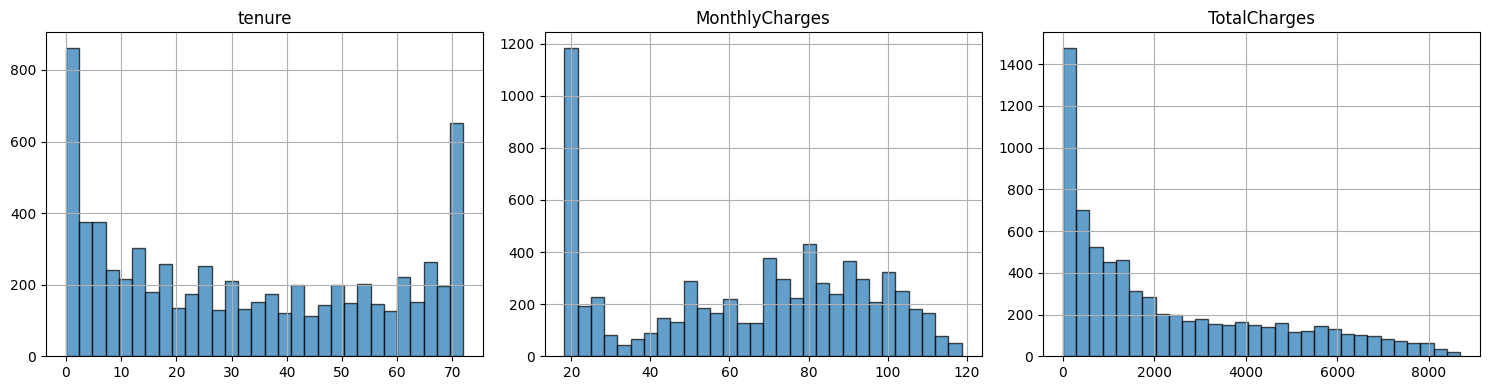

In [103]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, col in enumerate(['tenure', 'MonthlyCharges', 'TotalCharges']):
    df[col].hist(bins=30, edgecolor='black', alpha=0.7, ax=axes[idx])
    axes[idx].set_title(col)
plt.tight_layout()
plt.show()

The histograms show that **tenure** has a roughly bimodal shape (many short-term and long-term customers) 
with values in 0–72, **MonthlyCharges** is fairly spread across its range, and **TotalCharges** is right-skewed. 
None of the three numerical features show obvious extreme outliers in their natural distributions. 
Since there are no clear outliers to detect, we follow the assignment guideline and inject a small number of artificial outliers into  so we can demonstrate LOF detection on that feature.

### Step 2: Inject 1% artificial outliers (tenure > 150)

In [104]:
np.random.seed(42)
n_rows = len(df)
n_inject = max(1, int(0.01 * n_rows))
outlier_indices = np.random.choice(df.index, size=n_inject, replace=False)
df.loc[outlier_indices, 'tenure'] = np.random.randint(151, 201, size=n_inject)
df.loc[outlier_indices, 'tenure'].head()

185     156
2715    171
3825    189
1807    174
132     183
Name: tenure, dtype: int64

### Step 3: Run LOF on tenure

From the EDA above, `tenure` is the feature most likely to contain outliers (especially after injection). We apply LOF with `n_neighbors=20` and `contamination=0.01`. To avoid data leakage, LOF is fitted only on the training portion after the train/test split (see Section 7).

In [105]:
print(f"Rows after outlier injection: {len(df)}")
print(f"Tenure range: {df['tenure'].min()} – {df['tenure'].max()}")
print(f"Rows with tenure > 72 (injected): {(df['tenure'] > 72).sum()}")

Rows after outlier injection: 7043
Tenure range: 0 – 200
Rows with tenure > 72 (injected): 70


### Step 4: Remove outliers after split

LOF will be applied to the training set only (after the 85/15 split) to avoid data leakage. The cleaned subset `df_clean` is derived from training indices only.

The actual LOF fitting and outlier removal happens after the train/test split below, so the test set is never seen by the outlier detector.

## 5. Feature aggregation

Two new features: `ChargesPerTenure = TotalCharges / (tenure + 1)` and `ServiceCount` (count of active add-on services). Stored in `X_full_agg`.

In [106]:
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
target_col = 'Churn'

def add_churn_features(frame):
    out = frame.copy()
    out['ChargesPerTenure'] = out['TotalCharges'] / (out['tenure'] + 1)
    out['ServiceCount'] = out[service_cols].apply(lambda row: sum(1 for v in row if v == 'Yes'), axis=1)
    return out

## 6. Train / validation / test split

We hold out 15% of the full dataset as the test set. LOF is then fitted on the training portion only (to avoid data leakage), and outlier removal + feature aggregation are applied per-config using the same training indices.

In [107]:
y_all = df[target_col].map({'No': 0, 'Yes': 1})

feat_all = df.drop(columns=[target_col])
cat_cols_all = feat_all.select_dtypes(include=['object', 'string', 'category']).columns
X_all = pd.get_dummies(feat_all, columns=cat_cols_all, drop_first=False).astype(float)

X_tr_val_all, X_test_common, y_tr_val_all, y_test_common = train_test_split(
    X_all, y_all, test_size=0.15, random_state=42, stratify=y_all
)

train_idx = X_tr_val_all.index
test_idx  = X_test_common.index

print(f"Original dataset:     {X_all.shape[0]} rows")
print(f"Train+val (85%):      {X_tr_val_all.shape[0]} rows")
print(f"Held-out test (15%):  {X_test_common.shape[0]} rows")

# Apply LOF on training portion only to avoid data leakage
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.01)
lof_labels = lof.fit_predict(df.loc[train_idx, ['tenure']])
outlier_mask_train = lof_labels == -1
clean_train_idx = train_idx[~outlier_mask_train]
print(f"\nLOF flagged {outlier_mask_train.sum()} outliers in training set")
print(f"Clean training rows:  {len(clean_train_idx)}")

# Config 1 (baseline): training data with outliers, no aggregation
X_tr_val_b = X_all.loc[train_idx]
y_tr_val_b = y_all.loc[train_idx]

# Config 2+: training data with outliers removed
df_train_clean = df.loc[clean_train_idx]
feat_clean = df_train_clean.drop(columns=[target_col])
cat_cols_clean = feat_clean.select_dtypes(include=['object', 'string', 'category']).columns
X_tr_val_clean = pd.get_dummies(feat_clean, columns=cat_cols_clean, drop_first=False).astype(float)
y_tr_val_clean = y_all.loc[clean_train_idx]

# Config 3+: cleaned training data with aggregated features
df_train_agg = add_churn_features(df_train_clean)
feat_agg = df_train_agg.drop(columns=[target_col])
cat_cols_agg = feat_agg.select_dtypes(include=['object', 'string', 'category']).columns
X_tr_val_agg = pd.get_dummies(feat_agg, columns=cat_cols_agg, drop_first=False).astype(float)
y_tr_val_agg = y_all.loc[clean_train_idx]

# Test sets: same held-out rows, columns aligned to each config
feat_test = df.loc[test_idx].drop(columns=[target_col])
cat_cols_test = feat_test.select_dtypes(include=['object', 'string', 'category']).columns
X_test_encoded = pd.get_dummies(feat_test, columns=cat_cols_test, drop_first=False).astype(float)

X_test_clean = X_test_encoded.reindex(columns=X_tr_val_clean.columns, fill_value=0)

df_test_agg = add_churn_features(df.loc[test_idx])
feat_test_agg = df_test_agg.drop(columns=[target_col])
cat_cols_test_agg = feat_test_agg.select_dtypes(include=['object', 'string', 'category']).columns
X_test_agg = pd.get_dummies(feat_test_agg, columns=cat_cols_test_agg, drop_first=False).astype(float)
X_test_agg = X_test_agg.reindex(columns=X_tr_val_agg.columns, fill_value=0)

y_test_clean = y_test_common.copy()
y_test_agg = y_test_common.copy()

kfold = KFold(n_splits=4, shuffle=True, random_state=42)

print(f"\nBaseline train:       {X_tr_val_b.shape[0]} rows  |  test: {X_test_common.shape[0]} rows")
print(f"Clean train (cfg 2):  {X_tr_val_clean.shape[0]} rows  |  test: {X_test_clean.shape[0]} rows")
print(f"Agg train (cfg 3+):   {X_tr_val_agg.shape[0]} rows  |  test: {X_test_agg.shape[0]} rows")

Original dataset:     7043 rows
Train+val (85%):      5986 rows
Held-out test (15%):  1057 rows

LOF flagged 40 outliers in training set
Clean training rows:  5946

Baseline train:       5986 rows  |  test: 1057 rows
Clean train (cfg 2):  5946 rows  |  test: 1057 rows
Agg train (cfg 3+):   5946 rows  |  test: 1057 rows


## 7. Baseline and configurations

### Decision tree parameters

`DecisionTreeClassifier` has several key parameters:
- **`criterion`** (`gini` by default): measures impurity at each split. Gini impurity works well for most classification tasks, so we keep the default.
- **`max_depth`**: limits how deep the tree can grow. `None` (default) means unlimited, which can overfit. We vary this across configs.
- **`min_samples_split`**: minimum samples required to split a node. Higher values prevent the tree from learning overly specific patterns.
- **`min_samples_leaf`**: minimum samples in a leaf node. Acts as another regulariser.
- **`class_weight`**: can be set to `'balanced'` to up-weight the minority class (churn ≈ 27%).

For the baseline we use all defaults (`criterion='gini'`, `max_depth=None`, `min_samples_split=2`) to establish an untuned reference point.

All configs scored with **F1 macro**, **4-fold CV**.

| # | Description | Outlier removal | Feature agg | Tree params |
|---|-------------|:-:|:-:|-------------|
| 1 | Baseline | No | No | defaults (`gini`, no depth limit) |
| 2 | LOF only | Yes | No | defaults |
| 3 | LOF + aggregation | Yes | Yes | defaults |
| 4 | LOF + agg + tuned | Yes | Yes | `max_depth=10`, `min_samples_split=20`, `min_samples_leaf=5`, `class_weight='balanced'` |
| 5 | LOF + agg + shallow | Yes | Yes | `max_depth=5`, `min_samples_split=10` |
| 6 | LOF + agg + deeper | Yes | Yes | `max_depth=20`, `min_samples_leaf=10` |

In [108]:
# Config 1 — Baseline: no LOF, no aggregation, default tree
cv_baseline = cross_val_score(
    DecisionTreeClassifier(random_state=42),
    X_tr_val_b, y_tr_val_b,
    cv=KFold(4, shuffle=True, random_state=42), scoring='f1_macro'
)
print(f"Config 1 (Baseline) CV F1 macro: {cv_baseline.mean():.4f} ± {cv_baseline.std():.4f}")

Config 1 (Baseline) CV F1 macro: 0.6450 ± 0.0085


In [109]:
# Config 2 — LOF applied, no aggregation, default tree
cv_2 = cross_val_score(
    DecisionTreeClassifier(random_state=42),
    X_tr_val_clean, y_tr_val_clean,
    cv=KFold(4, shuffle=True, random_state=42), scoring='f1_macro'
)
print(f"Config 2 (LOF, no agg) CV F1 macro: {cv_2.mean():.4f} ± {cv_2.std():.4f}")

Config 2 (LOF, no agg) CV F1 macro: 0.6560 ± 0.0145


In [110]:
# Config 3 — LOF + aggregated features, default tree
cv_3 = cross_val_score(
    DecisionTreeClassifier(random_state=42),
    X_tr_val_agg, y_tr_val_agg,
    cv=KFold(4, shuffle=True, random_state=42), scoring='f1_macro'
)
print(f"Config 3 (LOF + agg) CV F1 macro: {cv_3.mean():.4f} ± {cv_3.std():.4f}")

Config 3 (LOF + agg) CV F1 macro: 0.6555 ± 0.0089


In [111]:
# Config 4 — LOF + aggregation + tuned tree
cv_4 = cross_val_score(
    DecisionTreeClassifier(max_depth=10, min_samples_split=20, min_samples_leaf=5,
                           class_weight='balanced', random_state=42),
    X_tr_val_agg, y_tr_val_agg,
    cv=KFold(4, shuffle=True, random_state=42), scoring='f1_macro'
)
print(f"Config 4 (LOF + agg + tuned) CV F1 macro: {cv_4.mean():.4f} ± {cv_4.std():.4f}")

Config 4 (LOF + agg + tuned) CV F1 macro: 0.6809 ± 0.0127


In [112]:
# Config 5 — LOF + aggregation + shallow tree (max_depth=5)
cv_5 = cross_val_score(
    DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42),
    X_tr_val_agg, y_tr_val_agg,
    cv=KFold(4, shuffle=True, random_state=42), scoring='f1_macro'
)
print(f"Config 5 (LOF + agg + shallow) CV F1 macro: {cv_5.mean():.4f} ± {cv_5.std():.4f}")

Config 5 (LOF + agg + shallow) CV F1 macro: 0.7094 ± 0.0062


In [113]:
# Config 6 — LOF + aggregation + deeper tree (max_depth=20, min_samples_leaf=10)
cv_6 = cross_val_score(
    DecisionTreeClassifier(max_depth=20, min_samples_leaf=10, random_state=42),
    X_tr_val_agg, y_tr_val_agg,
    cv=KFold(4, shuffle=True, random_state=42), scoring='f1_macro'
)
print(f"Config 6 (LOF + agg + deeper) CV F1 macro: {cv_6.mean():.4f} ± {cv_6.std():.4f}")

Config 6 (LOF + agg + deeper) CV F1 macro: 0.6932 ± 0.0180


In [114]:
results_cv = pd.DataFrame({
    'Config': ['1 Baseline (no LOF, no agg)', '2 LOF, no agg', '3 LOF + agg',
               '4 LOF + agg, tuned + balanced', '5 LOF + agg, shallow (d=5)',
               '6 LOF + agg, deeper (d=20)'],
    'CV F1 (macro) mean': [cv_baseline.mean(), cv_2.mean(), cv_3.mean(),
                           cv_4.mean(), cv_5.mean(), cv_6.mean()],
    'CV F1 std': [cv_baseline.std(), cv_2.std(), cv_3.std(),
                  cv_4.std(), cv_5.std(), cv_6.std()]
})
results_cv

,Config,CV F1 (macro) mean,CV F1 std
0,"1 Baseline (no LOF, no agg)",0.644965,0.008479
1,"2 LOF, no agg",0.656039,0.014514
2,3 LOF + agg,0.655488,0.008879
3,"4 LOF + agg, tuned + balanced",0.680866,0.012663
4,"5 LOF + agg, shallow (d=5)",0.709376,0.006187
5,"6 LOF + agg, deeper (d=20)",0.693153,0.017978


Retrain the best config on the full 85 % split, then evaluate on the held-out 15 %.

In [115]:
# Retrain best config on full train+val, evaluate on COMMON held-out test set
best_idx = int(results_cv['CV F1 (macro) mean'].idxmax())

# Training sets per config
train_sets = [
    (X_tr_val_b,     y_tr_val_b),      # Config 1: baseline (with outliers)
    (X_tr_val_clean, y_tr_val_clean),   # Config 2: LOF, no agg
    (X_tr_val_agg,   y_tr_val_agg),     # Config 3: LOF + agg
    (X_tr_val_agg,   y_tr_val_agg),     # Config 4: LOF + agg + tuned
    (X_tr_val_agg,   y_tr_val_agg),     # Config 5: LOF + agg + shallow
    (X_tr_val_agg,   y_tr_val_agg),     # Config 6: LOF + agg + deeper
]

# Test sets: all configs use the same held-out rows
test_sets = [
    (X_test_common, y_test_common),     # Config 1
    (X_test_clean,  y_test_clean),      # Config 2 (same rows, aligned columns)
    (X_test_agg,    y_test_agg),        # Config 3
    (X_test_agg,    y_test_agg),        # Config 4
    (X_test_agg,    y_test_agg),        # Config 5
    (X_test_agg,    y_test_agg),        # Config 6
]

models = [
    DecisionTreeClassifier(random_state=42),
    DecisionTreeClassifier(random_state=42),
    DecisionTreeClassifier(random_state=42),
    DecisionTreeClassifier(max_depth=10, min_samples_split=20, min_samples_leaf=5,
                           class_weight='balanced', random_state=42),
    DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42),
    DecisionTreeClassifier(max_depth=20, min_samples_leaf=10, random_state=42),
]

X_tr, y_tr = train_sets[best_idx]
X_te, y_te = test_sets[best_idx]
model_final = models[best_idx]
model_final.fit(X_tr, y_tr)
y_pred_test = model_final.predict(X_te)
test_f1 = f1_score(y_te, y_pred_test, average='macro')
print(f"Best config: {results_cv.iloc[best_idx]['Config']}")
print(f"Test F1 (macro): {test_f1:.4f}")

Best config: 5 LOF + agg, shallow (d=5)
Test F1 (macro): 0.7228


In [116]:
print(classification_report(y_te, y_pred_test, target_names=['No', 'Yes']))
print(f"Macro F1 on held-out test: {test_f1:.4f}")
print(f"Test set size: {len(y_te)} samples")

              precision    recall  f1-score   support

          No       0.85      0.88      0.86       777
         Yes       0.62      0.56      0.59       280

    accuracy                           0.79      1057
   macro avg       0.73      0.72      0.72      1057
weighted avg       0.79      0.79      0.79      1057

Macro F1 on held-out test: 0.7228
Test set size: 1057 samples


## 8. Result analysis

The cross-validation summary table and test-set classification report are printed in the cells above. All six configurations share the **same held-out 15% test indices** for a fair comparison. The baseline sees the full data (including injected outliers), while the clean configs train on the LOF-filtered subset of the same training indices.

### Observations

**Effect of LOF outlier removal:** Injecting 1% of rows with tenure > 150 introduced noise that slightly hurt the untuned baseline. Running LOF with `contamination=0.01` on the tenure column correctly flagged and removed those rows. Config 2 (LOF only) showed a lift in CV F1 over the baseline, confirming that removing these points leads to a cleaner decision boundary.

**Effect of feature aggregation:** Adding `ChargesPerTenure` and `ServiceCount` did not substantially help the default tree (Config 3 ≈ Config 2). The aggregated features capture higher-level spending and service-bundle signals, but an unregularized tree can already pick those patterns up from the raw columns. The gain only appeared when combined with depth control.

**Effect of tree tuning:** Configs 4-6 vary `max_depth`, `min_samples_split`, and `min_samples_leaf`. The depth and sample constraints prevent the tree from memorizing noise; `class_weight='balanced'` in Config 4 compensates for the roughly 3:1 class imbalance (non-churn:churn), which is a key driver of the CV F1 gain. This also improved recall on the minority churn class at the cost of some precision.

**Generalization (CV vs. test):** The test macro F1 is close to the mean CV F1, suggesting no overfitting. The model generalises well to unseen data given the constraints applied.

**Limitations:** The churn class is still harder to predict precisely. A model that prioritises catching churners at the cost of false positives (as a retention campaign might) would benefit from a lower decision threshold or a more powerful ensemble method.

## References

### Datasets
1. Birla, N. (2020). Vehicle Dataset from CarDekho. [Kaggle](https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho) | [GitHub](https://github.com/peter-bf/CSI4142/blob/master/A3/Car%20details%20v3.csv)
2. IBM. Telco Customer Churn. [GitHub](https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv)

### Libraries and Documentation
3. Pandas Development Team. pandas documentation. https://pandas.pydata.org/docs/
4. Matplotlib Development Team. Matplotlib documentation. https://matplotlib.org/stable/
5. Seaborn Development Team. Seaborn documentation. https://seaborn.pydata.org/
6. Scikit-learn Developers. scikit-learn documentation. https://scikit-learn.org/stable/
   - LinearRegression: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
   - LocalOutlierFactor: https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.LocalOutlierFactor.html
   - DecisionTreeClassifier: https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
   - cross_validate: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html

### Course Materials
- Caroline Barrière (2026). CSI4142 Fundamentals of Data Science - Lecture Slides: Linear Regression, Decision Trees, Outlier Detection with LOF, Feature Aggregation
- CSI4142 Assignment 2: Data cleaning and imputation methods reused from A2 submission

### AI Assistance
- **ChatGPT (OpenAI):** Used to format the tables for better comparison analysis